The dataset includes laboratory-defined rule-based classifications (PRECISION_STATUS) for duplicate measurements. This analysis explores whether unsupervised learning techniques can identify additional patterns or anomalies not captured by these predefined rules.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest


In [2]:
df = pd.read_csv(
    "../data/raw/ResultSet.csv",
    dtype={"INSTRUMENT_ID": "string"}
)

df.head()


,ANALYTICAL_TYPE,STD_LOT_CODE,STD_CODE,JOB_CODE,NUMERIC_FINAL_VALUE,ANALYSED_DATE,SCHEME_CODE,ANALYTE_CODE,STANDARD_STATUS,PRECISION_STATUS,...,INTERNAL_MAX_WARNING_INCLUSIVE,LIM_REP_VALUE,STAT_DL_VALUE,LIM_REP_DUP_VALUE,STAT_DL_DUP_VALUE,INTERNAL_TARGET_VALUE,PARENT_NUMERIC_FINAL_VALUE,UNIT_CODE,SPECIFICATION_CODE,INSTRUMENT_ID
0,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,35.927171,2021-11-22 16:37:52.000000,GE_IMS40Q12,PB,UpperFailure,NaN,...,Y,10,1.25,15.0,1.25,30.40,NaN,MG_KG,OREAS_905,<NA>
1,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,55.639610,2021-11-22 16:37:52.000000,GE_IMS40Q12,PB,UpperFailure,NaN,...,Y,10,1.25,15.0,1.25,30.40,NaN,MG_KG,OREAS_905,<NA>
2,Replicate,Sample,Sample,TSV_LB0016663011,1492.268392,2021-11-22 16:37:52.000000,GE_IMS40Q12,PB,NaN,Warning,...,NaN,10,1.25,15.0,1.25,NaN,1385.198107,MG_KG,NaN,<NA>
3,Replicate,Sample,Sample,TSV_LB0016663011,18.525452,2021-11-22 16:37:33.000000,GE_IMS40Q12,NI,NaN,Pass,...,NaN,10,5.00,15.0,5.00,NaN,16.334782,MG_KG,NaN,<NA>
4,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,11.742601,2021-11-22 16:37:33.000000,GE_IMS40Q12,NI,UpperWarning,NaN,...,Y,10,5.00,15.0,5.00,9.54,NaN,MG_KG,OREAS_905,<NA>


In [3]:
# INSTRUMENT_ID is effectively empty:
# - 99,998 out of 99,999 rows are NULL
# - Only one populated value exists
# Therefore, it provides no useful analytical value for this exploration.

df = df.drop(columns=["INSTRUMENT_ID"])


In [4]:
# df[df["ANALYTICAL_TYPE"] == "Duplicate"].head()
# Filter duplicates
df_duplicates = df[df["ANALYTICAL_TYPE"].str.strip().str.lower() == "duplicate"].copy()

# Export to CSV
df_duplicates.to_csv("../data/processed/duplicates_only.csv", index=False)


In [5]:
df_duplicates.shape


(5075, 26)

In [6]:
df_duplicates["ANALYTE_CODE"].value_counts().head(10)


ANALYTE_CODE
BI    141
RB    136
AL    136
P     136
MN    135
MG    135
CO    135
CA    133
U     132
ZN    132
Name: count, dtype: int64

df_group_stats = (
    df_duplicates
    .groupby(["JOB_CODE", "ANALYTE_CODE", "ANALYSED_DATE"])
    ["NUMERIC_FINAL_VALUE"]
    .agg(
        count="count",
        min_val="min",
        max_val="max",
        mean_val="mean",
        std_dev="std"
    )
    .reset_index()
)

df_group_stats #.head()

In [7]:
df_duplicates_BI = df_duplicates[df_duplicates["ANALYTE_CODE"] == "BI"].copy()

# Export to CSV
df_duplicates_BI.to_csv("../data/processed/duplicates_BI_only.csv", index=False)


In [8]:
df_duplicates_BI["ANALYTE_CODE"].unique()

<StringArray>
['BI']
Length: 1, dtype: str

In [9]:
df_duplicates_BI[["NUMERIC_FINAL_VALUE", "PARENT_NUMERIC_FINAL_VALUE"]].isna().sum()

NUMERIC_FINAL_VALUE           0
PARENT_NUMERIC_FINAL_VALUE    0
dtype: int64

In [10]:
df_duplicates_BI["PRECISION_STATUS"].value_counts()

PRECISION_STATUS
Pass             104
Warning           24
IgnoreFailure     12
Failure            1
Name: count, dtype: int64

In [11]:
df_bi = df_duplicates_BI.copy()

# Absolute difference between duplicate and original measurement
df_bi["ABS_DIFF"] = abs(
    df_bi["NUMERIC_FINAL_VALUE"] - df_bi["PARENT_NUMERIC_FINAL_VALUE"]
)

# Relative Percent Difference (RPD)
df_bi["RPD"] = np.where(
    (df_bi["NUMERIC_FINAL_VALUE"] + df_bi["PARENT_NUMERIC_FINAL_VALUE"]) != 0,
    df_bi["ABS_DIFF"] /
    ((df_bi["NUMERIC_FINAL_VALUE"] + df_bi["PARENT_NUMERIC_FINAL_VALUE"]) / 2) * 100,
    np.nan
)

# Average concentration across parent and duplicate
df_bi["MEAN_VALUE"] = (
    df_bi["NUMERIC_FINAL_VALUE"] + df_bi["PARENT_NUMERIC_FINAL_VALUE"]
) / 2

# Log transform only valid positive means
df_bi["LOG_MEAN"] = np.where(
    df_bi["MEAN_VALUE"] > 0,
    np.log10(df_bi["MEAN_VALUE"]),
    np.nan
)

df_bi[["NUMERIC_FINAL_VALUE", "PARENT_NUMERIC_FINAL_VALUE", "ABS_DIFF", "RPD", "MEAN_VALUE", "LOG_MEAN"]].head()


C:\Users\bobcl\anaconda3\envs\capstone_env\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,NUMERIC_FINAL_VALUE,PARENT_NUMERIC_FINAL_VALUE,ABS_DIFF,RPD,MEAN_VALUE,LOG_MEAN
31497,5.486792,7.464151,1.977358,30.536131,6.475472,0.811271
31499,7.149758,5.131313,2.018445,32.870834,6.140536,0.788206
31505,4.120219,-7.283019,11.403237,-721.084887,-1.581400,NaN
31527,-2.386885,-0.647805,1.739080,-114.613374,-1.517345,NaN
32378,-14.250000,-10.047847,4.202153,-34.588687,-12.148924,NaN


In [12]:
features = df_bi[["RPD", "LOG_MEAN"]].replace([np.inf, -np.inf], np.nan).dropna()

print("Original BI rows:", len(df_bi))
print("Rows available for modelling:", len(features))
print("Rows excluded:", len(df_bi) - len(features))


Original BI rows: 141
Rows available for modelling: 72
Rows excluded: 69


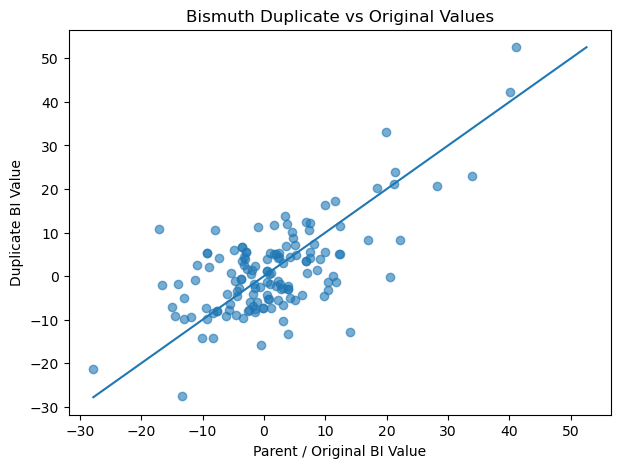

In [13]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df_bi["PARENT_NUMERIC_FINAL_VALUE"],
    df_bi["NUMERIC_FINAL_VALUE"],
    alpha=0.6
)

min_val = min(df_bi["PARENT_NUMERIC_FINAL_VALUE"].min(), df_bi["NUMERIC_FINAL_VALUE"].min())
max_val = max(df_bi["PARENT_NUMERIC_FINAL_VALUE"].max(), df_bi["NUMERIC_FINAL_VALUE"].max())

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Parent / Original BI Value")
plt.ylabel("Duplicate BI Value")
plt.title("Bismuth Duplicate vs Original Values")
plt.show()


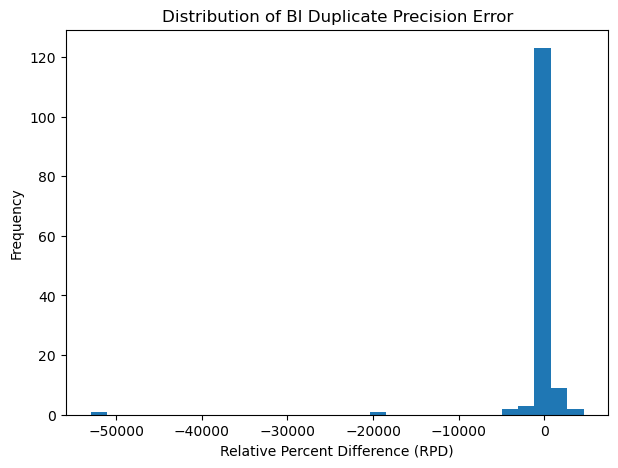

In [14]:
plt.figure(figsize=(7, 5))

plt.hist(df_bi["RPD"].dropna(), bins=30)

plt.xlabel("Relative Percent Difference (RPD)")
plt.ylabel("Frequency")
plt.title("Distribution of BI Duplicate Precision Error")
plt.show()


In [15]:
scaler = StandardScaler()
X = scaler.fit_transform(features)

X.shape


(72, 2)

In [16]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df_bi["CLUSTER"] = np.nan
df_bi.loc[features.index, "CLUSTER"] = kmeans.fit_predict(X)

df_bi["CLUSTER"].value_counts(dropna=False)


C:\Users\bobcl\anaconda3\envs\capstone_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


CLUSTER
NaN    69
2.0    50
1.0    20
0.0     2
Name: count, dtype: int64

In [17]:
df_bi.groupby("CLUSTER")["PRECISION_STATUS"].value_counts()


CLUSTER  PRECISION_STATUS
0.0      IgnoreFailure        1
         Pass                 1
1.0      Pass                12
         Warning              6
         IgnoreFailure        2
2.0      Pass                39
         Warning              9
         IgnoreFailure        2
Name: count, dtype: int64

In [18]:
df_bi.groupby("CLUSTER")[["RPD", "MEAN_VALUE", "LOG_MEAN", "ABS_DIFF"]].agg(
    ["count", "mean", "median", "min", "max"]
)


RPD                                                     MEAN_VALUE  \
        count         mean       median          min          max      count   
CLUSTER                                                                        
0.0         2  4189.085698  4189.085698  3779.971388  4598.200008          2   
1.0        20   854.067545   685.204192    47.507031  1928.366762         20   
2.0        50    84.563979    61.122656     0.000000   376.169859         50   

                                                  LOG_MEAN            \
              mean    median       min        max    count      mean   
CLUSTER                                                                
0.0       0.371046  0.371046  0.158145   0.583947        2 -0.517286   
1.0       0.920533  0.798511  0.383867   2.568047       20 -0.095970   
2.0      10.317384  6.665721  2.205547  46.842958       50  0.890345   

                                      ABS_DIFF                        \
           median       min       max    count       mean     median   
CLUSTER                                                                
0.0     -0.517286 -0.800945 -0.233626        2  16.414445  16.414445   
1.0     -0.097719 -0.415819  0.409603       20   6.974243   7.032355   
2.0      0.823847  0.343516  1.670644       50   5.946925   4.514231   

                              
              min        max  
CLUSTER                       
0.0      5.977828  26.851063  
1.0      0.315000  18.601364  
2.0      0.000000  20.913053

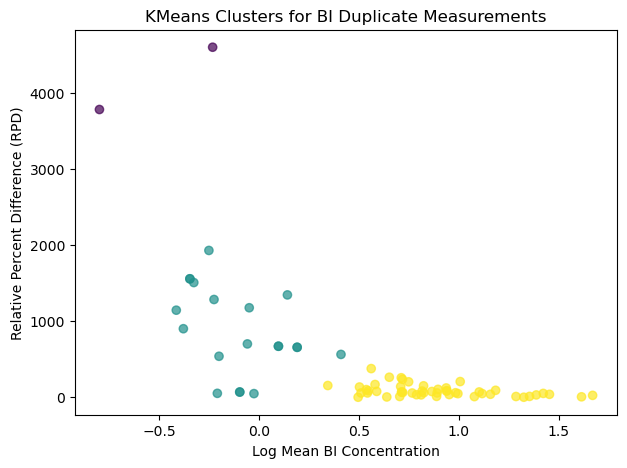

In [19]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df_bi.loc[features.index, "LOG_MEAN"],
    df_bi.loc[features.index, "RPD"],
    c=df_bi.loc[features.index, "CLUSTER"],
    alpha=0.7
)

plt.xlabel("Log Mean BI Concentration")
plt.ylabel("Relative Percent Difference (RPD)")
plt.title("KMeans Clusters for BI Duplicate Measurements")
plt.show()


In [20]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

df_bi["ANOMALY_SCORE"] = np.nan
df_bi.loc[features.index, "ANOMALY_SCORE"] = iso.fit_predict(X)

df_bi["ANOMALY_SCORE"].value_counts(dropna=False)


ANOMALY_SCORE
 NaN    69
 1.0    68
-1.0     4
Name: count, dtype: int64

In [21]:
df_bi.groupby("ANOMALY_SCORE")["PRECISION_STATUS"].value_counts()


ANOMALY_SCORE  PRECISION_STATUS
-1.0           Pass                 2
               Warning              1
               IgnoreFailure        1
 1.0           Pass                50
               Warning             14
               IgnoreFailure        4
Name: count, dtype: int64

In [22]:
df_bi[df_bi["ANOMALY_SCORE"] == -1][[
    "JOB_CODE",
    "ANALYTE_CODE",
    "NUMERIC_FINAL_VALUE",
    "PARENT_NUMERIC_FINAL_VALUE",
    "ABS_DIFF",
    "RPD",
    "MEAN_VALUE",
    "LOG_MEAN",
    "PRECISION_STATUS",
    "CLUSTER",
    "ANOMALY_SCORE"
]].sort_values("RPD", ascending=False)


,JOB_CODE,ANALYTE_CODE,NUMERIC_FINAL_VALUE,PARENT_NUMERIC_FINAL_VALUE,ABS_DIFF,RPD,MEAN_VALUE,LOG_MEAN,PRECISION_STATUS,CLUSTER,ANOMALY_SCORE
64952,TSV_LB0004562034,BI,-12.841584,14.009479,26.851063,4598.200008,0.583947,-0.233626,IgnoreFailure,0.0,-1.0
59194,TSV_LB0004835725,BI,-2.830769,3.147059,5.977828,3779.971388,0.158145,-0.800945,Pass,0.0,-1.0
60644,TSV_LB0004797270,BI,5.951923,-4.833333,10.785256,1928.366762,0.559295,-0.252359,Warning,1.0,-1.0
99379,TSV_LB0002672605,BI,52.563636,41.122280,11.441357,24.424923,46.842958,1.670644,Pass,2.0,-1.0


In [23]:
df_bi.to_csv(
    "../data/processed/duplicates_BI_enriched.csv",
    index=False
)
